# quiz 1

In [1]:
from pathlib import Path
from sklearn.model_selection import StratifiedKFold
from other_code.quiz1 import *

In [2]:
categories = ["Bean", "Bitter_Gourd", "Bottle_Gourd", "Brinjal", "Broccoli", "Cabbage", "Capsicum", "Carrot", "Cauliflower",
              "Cucumber", "Papaya", "Potato", "Pumpkin", "Radish", "Tomato"]
class_to_idx = {name: idx for idx, name in enumerate(categories)}

data_root = Path(r"./dataset/Vegetable Images")

train_records = scan_images("train", data_root, categories, class_to_idx)
test_records = scan_images("test", data_root, categories, class_to_idx)

print("train 圖片數：", len(train_records))
print("test 圖片數：", len(test_records))

train 圖片數： 18000
test 圖片數： 3000


In [3]:
labels = [label for image_path, label in train_records]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

folds = list(skf.split(train_records, labels))

for fold_no, (train_idx, val_idx) in enumerate(folds, start=1):
    print(f"Fold {fold_no}: train={len(train_idx)}, val={len(val_idx)}")

Fold 1: train=14400, val=3600
Fold 2: train=14400, val=3600
Fold 3: train=14400, val=3600
Fold 4: train=14400, val=3600
Fold 5: train=14400, val=3600


# quiz 2 基礎

In [4]:
import torch
import importlib
from torch.utils.data import DataLoader
from torchvision import transforms
from other_code import quiz2
importlib.reload(quiz2)
from other_code.quiz2 import *

In [ ]:
Batch_size = 64
Num_epochs = 15
Learning_rate = 0.0005

basic_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda



========== Fold 1 ==========
Epoch 01 | Train loss 1.2191, acc 0.6474 | Val loss 0.7926, acc 0.7539
Epoch 02 | Train loss 0.5184, acc 0.8458 | Val loss 0.6260, acc 0.7953
Epoch 03 | Train loss 0.3380, acc 0.9019 | Val loss 0.3038, acc 0.9111
Epoch 04 | Train loss 0.2483, acc 0.9284 | Val loss 0.3304, acc 0.8875
Epoch 05 | Train loss 0.2005, acc 0.9401 | Val loss 0.1531, acc 0.9550
Epoch 06 | Train loss 0.1761, acc 0.9479 | Val loss 0.1729, acc 0.9519
Epoch 07 | Train loss 0.1407, acc 0.9592 | Val loss 0.1405, acc 0.9569
Epoch 08 | Train loss 0.1308, acc 0.9606 | Val loss 0.3892, acc 0.8736
Epoch 09 | Train loss 0.1088, acc 0.9689 | Val loss 0.3774, acc 0.8694
Epoch 10 | Train loss 0.0964, acc 0.9717 | Val loss 0.0997, acc 0.9678
Epoch 11 | Train loss 0.0914, acc 0.9728 | Val loss 0.7179, acc 0.8081
Epoch 12 | Train loss 0.0933, acc 0.9717 | Val loss 0.0649, acc 0.9817
Epoch 13 | Train loss 0.0735, acc 0.9788 | Val loss 0.0948, acc 0.9675
Epoch 14 | Train loss 0.0697, acc 0.9797 | Val 

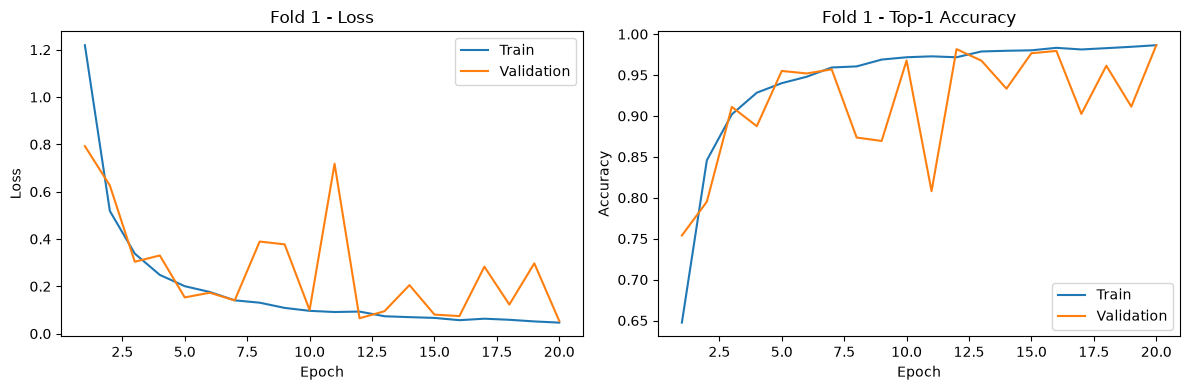

Fold 1 最佳：Epoch 20, Val loss 0.0534, Val acc 0.9864

========== Fold 2 ==========
Epoch 01 | Train loss 1.2352, acc 0.6358 | Val loss 1.1121, acc 0.6078
Epoch 02 | Train loss 0.5226, acc 0.8448 | Val loss 0.3673, acc 0.8997
Epoch 03 | Train loss 0.3478, acc 0.8976 | Val loss 0.2604, acc 0.9156
Epoch 04 | Train loss 0.2526, acc 0.9237 | Val loss 0.3184, acc 0.8950
Epoch 05 | Train loss 0.2236, acc 0.9319 | Val loss 0.1513, acc 0.9569
Epoch 06 | Train loss 0.1730, acc 0.9484 | Val loss 0.1121, acc 0.9692
Epoch 07 | Train loss 0.1515, acc 0.9558 | Val loss 0.1128, acc 0.9708
Epoch 08 | Train loss 0.1350, acc 0.9585 | Val loss 0.1842, acc 0.9400
Epoch 09 | Train loss 0.1209, acc 0.9637 | Val loss 0.1105, acc 0.9717
Epoch 10 | Train loss 0.1069, acc 0.9680 | Val loss 0.1475, acc 0.9589
Epoch 11 | Train loss 0.1040, acc 0.9693 | Val loss 0.0877, acc 0.9775
Epoch 12 | Train loss 0.0805, acc 0.9775 | Val loss 0.1471, acc 0.9581
Epoch 13 | Train loss 0.0809, acc 0.9756 | Val loss 0.1180, acc 0.

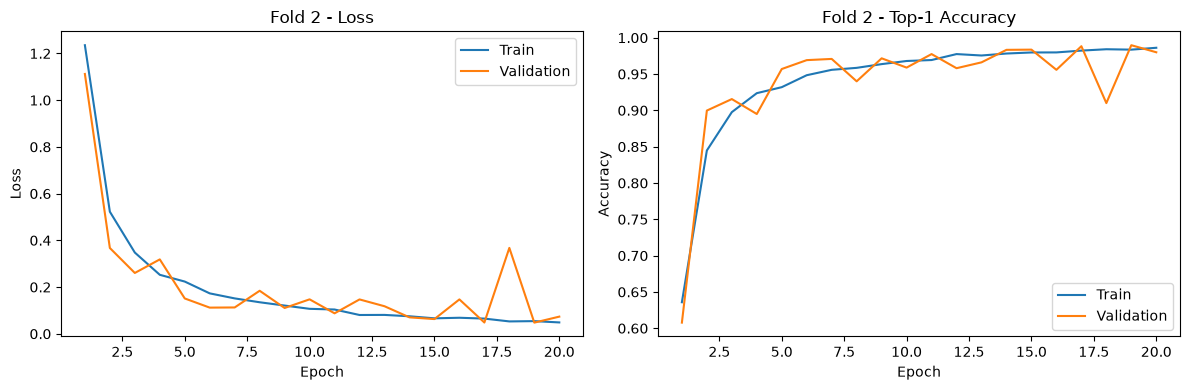

Fold 2 最佳：Epoch 19, Val loss 0.0479, Val acc 0.9897

========== Fold 3 ==========
Epoch 01 | Train loss 1.2083, acc 0.6578 | Val loss 0.7447, acc 0.7536
Epoch 02 | Train loss 0.5012, acc 0.8523 | Val loss 0.7199, acc 0.7886
Epoch 03 | Train loss 0.3384, acc 0.9012 | Val loss 0.6718, acc 0.7792
Epoch 04 | Train loss 0.2636, acc 0.9246 | Val loss 0.3482, acc 0.8808
Epoch 05 | Train loss 0.2101, acc 0.9376 | Val loss 0.3187, acc 0.8972
Epoch 06 | Train loss 0.1724, acc 0.9512 | Val loss 0.6617, acc 0.8061
Epoch 07 | Train loss 0.1389, acc 0.9610 | Val loss 0.1284, acc 0.9606


KeyboardInterrupt: 

In [ ]:
Checkpoint_dir = "./checkpoints/PlainCNN"
fold_results = train_five_folds(model_class=PlainCNN, train_records=train_records, folds=folds, categories=categories, transform=basic_transform,
                                device=device, num_epochs=Num_epochs, batch_size=Batch_size,learning_rate=Learning_rate, checkpoint_dir=Checkpoint_dir)

In [ ]:
Result_path = "./result/quiz2_plain_cnn_roc.png"

best_fold = min(fold_results, key=lambda result: result["val_loss"])

model = PlainCNN(num_classes=len(categories))
test_results, test_labels, test_probs = test(model=model, checkpoint_path=best_fold["checkpoint"], test_records=test_records,
    transform=basic_transform, device=device, batch_size=64)
roc_results = plot_roc_auc(labels=test_labels, probs=test_probs, categories=categories, model_name="Plain CNN", result_path=Result_path)

NameError: name 'fold_results' is not defined

In [ ]:
resnet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

Checkpoint_dir = "./checkpoints/resnet"
resnet_results = train_five_folds(model_class=ResNet18Transfer, train_records=train_records, folds=folds, categories=categories, transform=resnet_transform, device=device,
                                num_epochs=Num_epochs, batch_size=Batch_size,learning_rate=Learning_rate, checkpoint_dir=Checkpoint_dir)

In [ ]:
Result_path = "./result/quiz2_resnet_roc.png"

best_fold = min(resnet_results, key=lambda result: result["val_loss"])

model = ResNet18Transfer(num_classes=len(categories))
test_results, test_labels, test_probs = test(model=model, checkpoint_path=best_fold["checkpoint"], test_records=test_records,
                                             transform=resnet_transform, device=device, batch_size=64)
roc_results = plot_roc_auc(labels=test_labels, probs=test_probs, categories=categories, model_name="resnet18", result_path=Result_path)